In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-04-24 07:14:34.037572: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 07:14:34.117650: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 07:14:34.519143: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 07:14:34.519265: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 07:14:34.522226: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [2]:
train_dir = '../../data/Training'
test_dir = '../../data/Testing'

In [3]:
for folder in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, folder)))
    print(f"{folder}: {count}")

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400


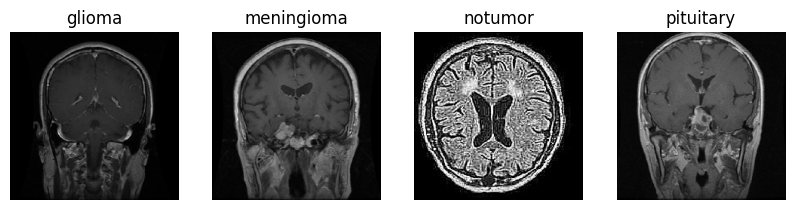

In [4]:
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(10,5))

for i, folder in enumerate(os.listdir(train_dir)):
    img_name = random.choice(os.listdir(os.path.join(train_dir, folder)))
    img_path = os.path.join(train_dir, folder, img_name)

    img = load_img(img_path, target_size=(224,224))

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.show()

In [5]:
valid_ext = ('.jpg', '.jpeg', '.png')

for folder in os.listdir(train_dir):
    for file in os.listdir(os.path.join(train_dir, folder)):
        if not file.lower().endswith(valid_ext):
            print("Invalid file:", file)

In [6]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1602 images belonging to 4 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

class_names = list(train_generator.class_indices.keys())
print(class_names)

# model = Sequential()

# model.add(Input(shape=(224,224,3)))

# # Block 1
# model.add(Conv2D(32, (3,3), activation='relu'))
# model.add(MaxPooling2D())
# model.add(BatchNormalization())

# # Block 2
# model.add(Conv2D(64, (3,3), activation='relu'))
# model.add(MaxPooling2D())
# model.add(BatchNormalization())

# # Block 3
# model.add(Conv2D(128, (3,3), activation='relu'))
# model.add(MaxPooling2D())
# model.add(BatchNormalization())

# # Block 4
# model.add(Conv2D(256, (3,3), activation='relu'))
# model.add(MaxPooling2D())
# model.add(BatchNormalization())


# model.add(Conv2D(256, (3,3), activation='relu'))
# model.add(MaxPooling2D())

# # GAP
# model.add(GlobalAveragePooling2D())

# # Classifier
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.4))
# model.add(Dense(len(class_names), activation='softmax'))

model = Sequential()

model.add(Input(shape=(224,224,3)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(Conv2D(32, (3,3), activation='relu')) 
model.add(MaxPooling2D())
model.add(BatchNormalization())

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))  
model.add(MaxPooling2D())
model.add(BatchNormalization())

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))  
model.add(MaxPooling2D())
model.add(BatchNormalization())

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D())

# GAP instead of Flatten
model.add(GlobalAveragePooling2D())

# Classifier
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(class_names), activation='softmax'))

model.summary()

['glioma', 'meningioma', 'notumor', 'pituitary']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 32)      0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 110, 110, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 108, 64)      18496     
                                                                 
 conv2d

In [9]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/25
140/140 [==============================] - 263s 2s/step - loss: 0.9124 - accuracy: 0.6241 - val_loss: 1.5060 - val_accuracy: 0.2500 - lr: 1.0000e-04
Epoch 2/25
140/140 [==============================] - 242s 2s/step - loss: 0.7150 - accuracy: 0.7239 - val_loss: 1.6202 - val_accuracy: 0.2509 - lr: 1.0000e-04
Epoch 3/25
140/140 [==============================] - 217s 2s/step - loss: 0.6379 - accuracy: 0.7489 - val_loss: 1.8130 - val_accuracy: 0.2661 - lr: 1.0000e-04
Epoch 4/25
140/140 [==============================] - 209s 1s/step - loss: 0.5414 - accuracy: 0.7926 - val_loss: 1.3899 - val_accuracy: 0.4393 - lr: 3.0000e-05
Epoch 5/25
140/140 [==============================] - 227s 2s/step - loss: 0.5117 - accuracy: 0.8096 - val_loss: 0.5975 - val_accuracy: 0.7661 - lr: 3.0000e-05
Epoch 6/25
140/140 [==============================] - 236s 2s/step - loss: 0.4831 - accuracy: 0.8170 - val_loss: 0.9101 - val_accuracy: 0.6313 - lr: 3.0000e-05
Epoch 7/25
140/140 [====================

In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

51/51 [==============================] - 27s 538ms/step - loss: 0.7513 - accuracy: 0.7484
Test Accuracy: 0.7484394311904907


In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# True labels
y_true = test_generator.classes

# Predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

51/51 [==============================] - 18s 332ms/step


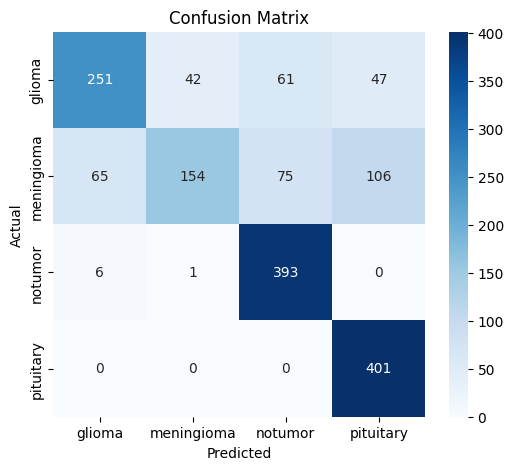

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      glioma       0.78      0.63      0.69       401
  meningioma       0.78      0.39      0.52       400
     notumor       0.74      0.98      0.85       400
   pituitary       0.72      1.00      0.84       401

    accuracy                           0.75      1602
   macro avg       0.76      0.75      0.72      1602
weighted avg       0.76      0.75      0.72      1602



In [17]:
import pandas as pd

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

print(df_report)

# Save to CSV
df_report.to_csv("classification_report.csv")

              precision    recall  f1-score      support
glioma         0.779503  0.625935  0.694329   401.000000
meningioma     0.781726  0.385000  0.515913   400.000000
notumor        0.742911  0.982500  0.846071   400.000000
pituitary      0.723827  1.000000  0.839791   401.000000
accuracy       0.748439  0.748439  0.748439     0.748439
macro avg      0.756992  0.748359  0.724026  1602.000000
weighted avg   0.756985  0.748439  0.724080  1602.000000


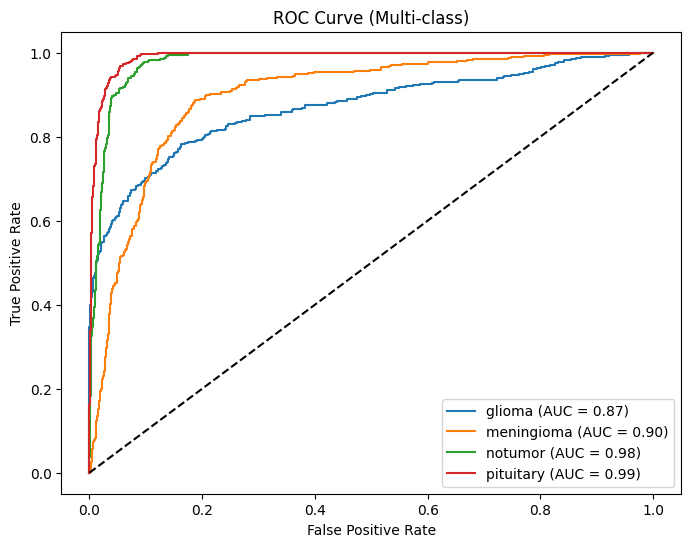

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

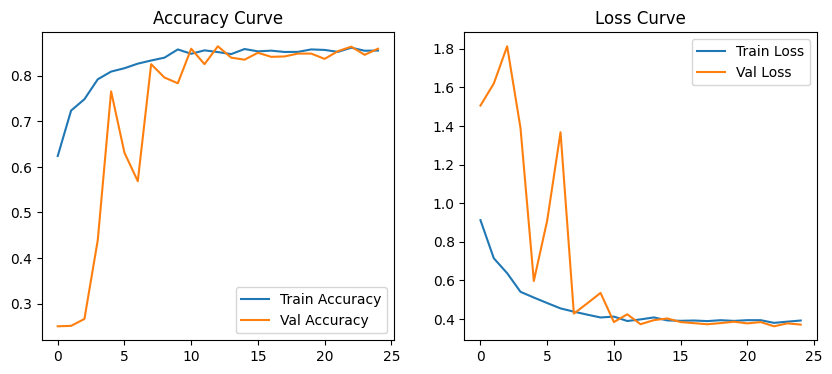

In [19]:
# Accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

In [20]:
model.save("brain_tumor_model_scratch.keras")

In [21]:
from tensorflow.keras.models import load_model
model = load_model("brain_tumor_model_scratch.keras")